# 08 — Iran Conflict Deep Dive

Analysis of security performance since the US-Iran conflict onset (Feb 28, 2026).
Sector-level aggregation, winners/losers, and conflict-period analytics.

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', '..')))

import pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from energy_workbook.config import ALL_TICKERS, EQUITY_TICKERS, RF_RATE

VIZ = os.path.abspath(os.path.join('..', 'visualization'))
DATA = os.path.abspath(os.path.join('..', 'data'))

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.titlesize': 14,
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#CCCCCC', 'axes.grid': True,
    'grid.alpha': 0.3, 'legend.fontsize': 9,
})
MC_COLORS = ['#002B5C','#1A3C6E','#4A86C8','#0070C0','#C89600',
             '#E06C00','#C00000','#008000','#7030A0','#666666']
cmap_rg = LinearSegmentedColormap.from_list('rg', ['#C00000','#FFFFFF','#006100'])

def savefig(fig, name, dpi=180):
    fig.savefig(os.path.join(VIZ, name), dpi=dpi, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    print(f'  saved {name}')

cache_path = os.path.abspath(os.path.join('..', '..', 'data_cache.pkl'))
with open(cache_path, 'rb') as f:
    D = pickle.load(f)
MASTER = D['master']; LOG_RET = D['log_returns']
print('Data loaded')

Data loaded


## 8.1 Iran Conflict Performance

In [6]:
iran_start = '2026-02-28'

iran_stats = {}
for t in ALL_TICKERS:
    r = LOG_RET.get(t, pd.Series(dtype=float))
    ri = r[r.index >= iran_start].dropna()
    if len(ri) > 0:
        iran_stats[t] = dict(
            cum_ret=float(np.exp(ri.sum()) - 1),
            ann_vol=float(ri.std() * np.sqrt(252)),
            n_days=len(ri),
            sharpe=float((ri.mean()*252 - RF_RATE) / (ri.std()*np.sqrt(252))) if ri.std() > 0 else 0,
            best_day=float(ri.max()),
            worst_day=float(ri.min()),
        )

iran_df = pd.DataFrame(iran_stats).T
iran_df.to_csv(os.path.join(DATA, 'iran_conflict_stats.csv'))

# Display
display_df = iran_df.copy()
for c in ['cum_ret', 'ann_vol', 'best_day', 'worst_day']:
    display_df[c] = (display_df[c] * 100).round(2).astype(str) + '%'
display_df['sharpe'] = display_df['sharpe'].round(3)
display_df['n_days'] = display_df['n_days'].astype(int)
display_df

,cum_ret,ann_vol,n_days,sharpe,best_day,worst_day
XOM,5.37%,28.16%,24,1.837,3.31%,-5.38%
CVX,6.54%,26.16%,24,2.420,2.91%,-4.7%
COP,15.04%,27.57%,24,5.219,4.13%,-2.78%
OXY,19.2%,35.07%,24,5.167,4.97%,-4.36%
LNG,19.27%,41.91%,24,4.339,5.71%,-3.52%
VG,51.29%,103.16%,24,4.183,16.08%,-8.09%
FRO,-0.5%,58.32%,24,-0.145,5.32%,-6.46%
STNG,-2.8%,49.22%,24,-0.670,6.09%,-8.31%
ET,0.48%,17.44%,24,0.104,2.43%,-1.57%
BIL,0.34%,0.18%,24,1.836,0.03%,-0.01%


## 8.2 Iran Conflict Cumulative Returns (Zoomed)

  saved 15_iran_conflict_zoom.png


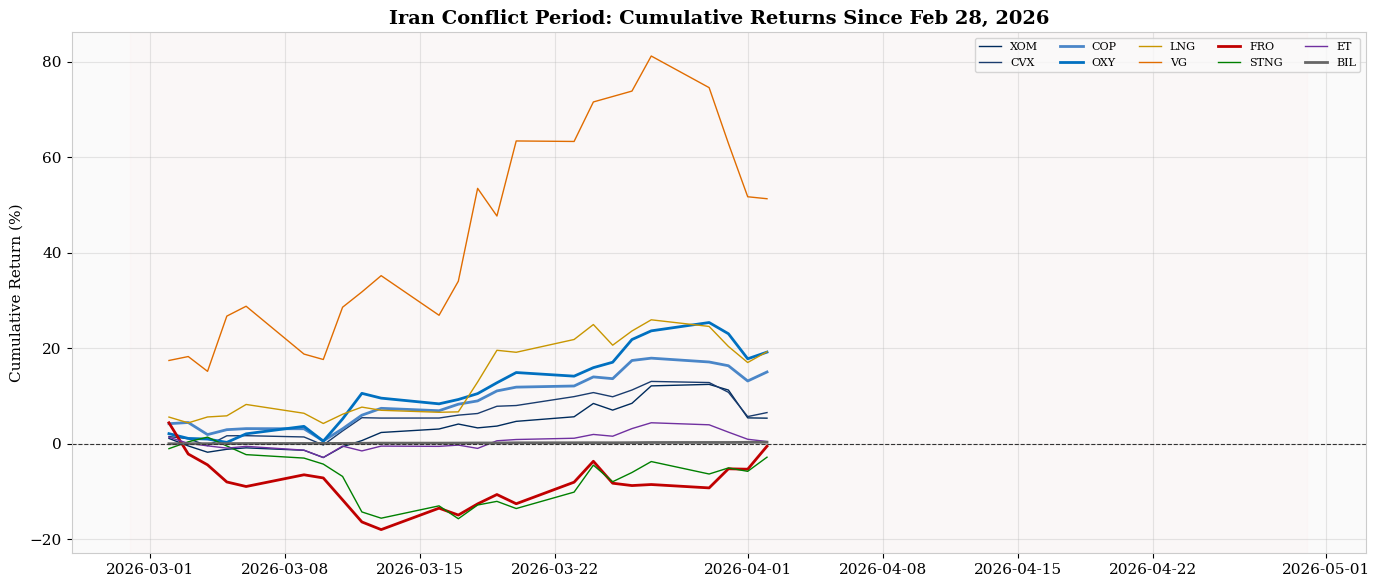

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
for i, t in enumerate(ALL_TICKERS):
    r = LOG_RET.get(t, pd.Series(dtype=float))
    ri = r[r.index >= iran_start].dropna()
    if len(ri) > 0:
        cum = (np.exp(ri.cumsum()) - 1) * 100
        ax.plot(cum.index, cum.values, label=t, color=MC_COLORS[i % len(MC_COLORS)],
                linewidth=2.0 if t in ['COP','FRO','OXY','BIL'] else 1.0)

ax.axhline(0, color='#333', linewidth=0.8, linestyle='--')
ax.axvspan(pd.Timestamp('2026-02-28'), pd.Timestamp('2026-04-30'),
           alpha=0.08, color='#FFD6D6', zorder=0)
ax.set_title('Iran Conflict Period: Cumulative Returns Since Feb 28, 2026', fontweight='bold')
ax.set_ylabel('Cumulative Return (%)')
ax.legend(ncol=5, fontsize=8)
fig.tight_layout()
savefig(fig, '15_iran_conflict_zoom.png')
plt.show()

## 8.3 Sector-Level Analysis

  saved 17_iran_sector_returns.png


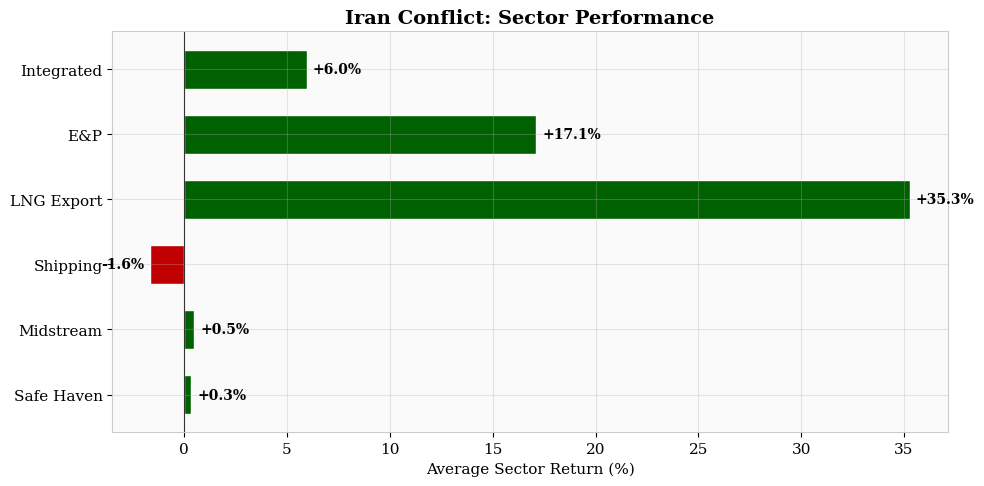

In [8]:
SECTOR_MAP = {
    'Integrated': ['XOM', 'CVX'],
    'E&P': ['COP', 'OXY'],
    'LNG Export': ['LNG', 'VG'],
    'Shipping': ['FRO', 'STNG'],
    'Midstream': ['ET'],
    'Safe Haven': ['BIL'],
}

sector_iran = {}
for s, ts in SECTOR_MAP.items():
    rets = [iran_stats.get(t, {}).get('cum_ret', 0) for t in ts]
    vols = [iran_stats.get(t, {}).get('ann_vol', 0) for t in ts]
    sector_iran[s] = {
        'avg_return': np.mean(rets) * 100,
        'avg_vol': np.mean(vols) * 100,
        'tickers': ', '.join(ts),
    }

fig, ax = plt.subplots(figsize=(10, 5))
sectors = list(sector_iran.keys())
returns = [sector_iran[s]['avg_return'] for s in sectors]
colors = ['#006100' if r > 0 else '#C00000' for r in returns]
bars = ax.barh(sectors[::-1], returns[::-1], color=colors[::-1], edgecolor='white', height=0.6)

for bar, val in zip(bars, returns[::-1]):
    x_pos = bar.get_width() + 0.3 if val > 0 else bar.get_width() - 0.3
    ha = 'left' if val > 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', ha=ha, fontsize=10, fontweight='bold')

ax.axvline(0, color='#333', linewidth=0.8)
ax.set_xlabel('Average Sector Return (%)')
ax.set_title('Iran Conflict: Sector Performance', fontweight='bold')
fig.tight_layout()
savefig(fig, '17_iran_sector_returns.png')
plt.show()

## 8.4 Winners & Losers Scorecard

  saved 27_iran_winners_losers.png


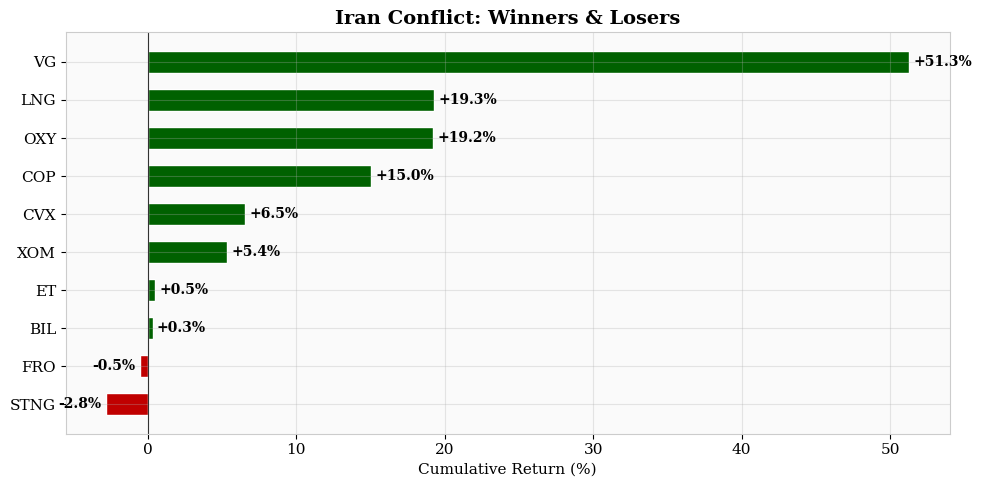

In [9]:
# Ranked bar chart
sorted_iran = sorted(iran_stats.items(), key=lambda x: x[1]['cum_ret'], reverse=True)

fig, ax = plt.subplots(figsize=(10, 5))
ts = [t for t, _ in sorted_iran]
rets = [s['cum_ret'] * 100 for _, s in sorted_iran]
colors = ['#006100' if r > 0 else '#C00000' for r in rets]

bars = ax.barh(ts[::-1], rets[::-1], color=colors[::-1], edgecolor='white', height=0.6)
for bar, val in zip(bars, rets[::-1]):
    x_pos = bar.get_width() + 0.3 if val > 0 else bar.get_width() - 0.3
    ha = 'left' if val > 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', ha=ha, fontsize=10, fontweight='bold')

ax.axvline(0, color='#333', linewidth=0.8)
ax.set_xlabel('Cumulative Return (%)')
ax.set_title('Iran Conflict: Winners & Losers', fontweight='bold')
fig.tight_layout()
savefig(fig, '27_iran_winners_losers.png')
plt.show()

## 8.5 ET vs BIL (Defensive Comparison)

  saved 28_et_vs_bil.png


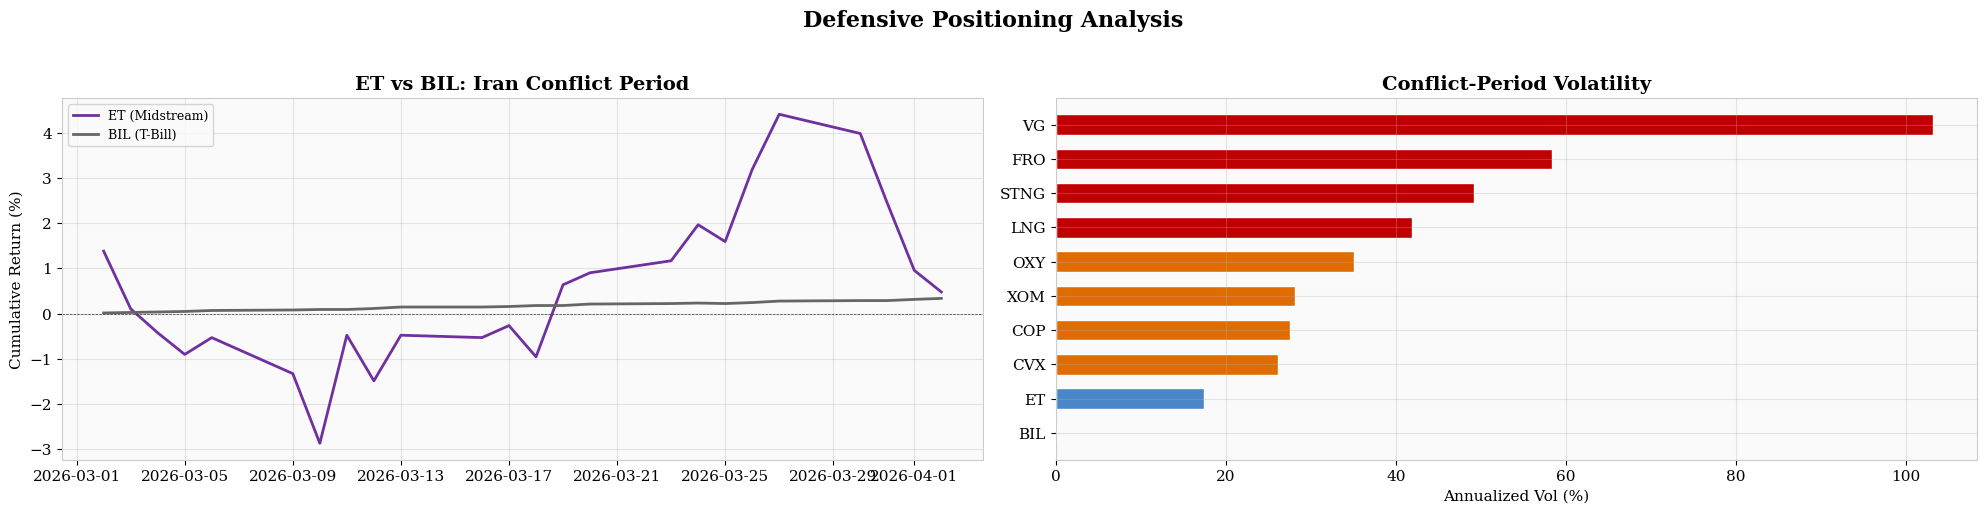

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))

# Price comparison
for t, ax_color, lbl in [('ET', '#7030A0', 'Midstream'), ('BIL', '#666666', 'T-Bill')]:
    r = LOG_RET.get(t, pd.Series(dtype=float))
    ri = r[r.index >= iran_start].dropna()
    if len(ri) > 0:
        cum = (np.exp(ri.cumsum()) - 1) * 100
        ax1.plot(cum.index, cum.values, label=f'{t} ({lbl})',
                 color=ax_color, linewidth=2)
ax1.axhline(0, color='#333', linewidth=0.5, linestyle='--')
ax1.set_title('ET vs BIL: Iran Conflict Period', fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(fontsize=9)

# Vol comparison during conflict
conflict_vols = {}
for t in ALL_TICKERS:
    r = LOG_RET.get(t, pd.Series(dtype=float))
    ri = r[r.index >= iran_start].dropna()
    if len(ri) > 5:
        conflict_vols[t] = ri.std() * np.sqrt(252) * 100

sv = sorted(conflict_vols.items(), key=lambda x: x[1], reverse=True)
ts = [t for t, _ in sv]; vv = [v for _, v in sv]
colors = ['#C00000' if v > 40 else '#E06C00' if v > 25 else '#4A86C8' for v in vv]
ax2.barh(ts[::-1], vv[::-1], color=colors[::-1], edgecolor='white', height=0.6)
ax2.set_xlabel('Annualized Vol (%)')
ax2.set_title('Conflict-Period Volatility', fontweight='bold')

fig.suptitle('Defensive Positioning Analysis', fontweight='bold', fontsize=16, y=1.02)
fig.tight_layout()
savefig(fig, '28_et_vs_bil.png')
plt.show()

## 8.6 Key Takeaways

**Iran Conflict (onset Feb 28, 2026):**
- **Shipping (FRO, STNG)** — biggest beneficiaries from route disruption & tanker demand
- **E&P (COP, OXY)** — direct oil price leverage via high betas
- **Integrated (XOM, CVX)** — moderate gains, diversified exposure dampens upside
- **BIL** — near-zero return as expected (risk-free proxy)
- **Correlation convergence** — crisis drives all energy names toward +1 correlation